# Prediksi Harga Emas Menggunakan Metode Long Short-Term Memory (LSTM)

**Proyek EAS - MK Pembelajaran Mesin**

**Variabel:**
- **Y**: Harga Emas (USD/troy oz)
- **X1**: Inflasi (%)
- **X2**: Kurs Rupiah (IDR/USD)
- **X3**: BI Rate (%)
- **X4**: Harga Minyak Dunia (Brent Crude, USD/barrel)

**Periode**: Januari 2020 – Juni 2026

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

print('TensorFlow version:', tf.__version__)
print('Pandas version:', pd.__version__)
print('Numpy version:', np.__version__)

# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TensorFlow version: 2.20.0
Pandas version: 2.2.2
Numpy version: 2.0.2


## 2. Load & Persiapan Data

> **Catatan**: Ganti bagian ini dengan data aktual Anda.
> Format file: Excel/CSV dengan kolom: Tanggal, Harga_Emas, Inflasi, Kurs_Rupiah, BI_Rate, Harga_Minyak
>
> Sumber data yang disarankan:
> - Harga Emas: investing.com / gold.org
> - Inflasi & BI Rate: bps.go.id / bi.go.id
> - Kurs Rupiah: bi.go.id (JISDOR)
> - Harga Minyak: investing.com (Brent Crude)

In [2]:
# ============================================================
# OPSI A: Load dari file Excel/CSV (GUNAKAN INI)
# ============================================================
df = pd.read_excel('/content/data_emas.xlsx', parse_dates=['Tanggal'])

# ============================================================
# OPSI B: Data Simulasi (untuk testing — hapus saat submit)
# ============================================================
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2026-06-01', freq='MS')
n = len(dates)

# Simulasi harga emas dengan tren naik + fluktuasi
trend = np.linspace(1500, 2400, n)
noise = np.random.normal(0, 50, n)
gold_prices = trend + noise
gold_prices[30:45] += 300   # simulasi lonjakan 2022
gold_prices[60:] += 200     # simulasi kenaikan 2025

df = pd.DataFrame({
    'Tanggal': dates,
    'Harga_Emas': np.round(gold_prices, 2),
    'Inflasi': np.round(np.random.uniform(1.5, 8.5, n), 2),
    'Kurs_Rupiah': np.round(np.random.uniform(14000, 16500, n), 0),
    'BI_Rate': np.round(np.random.uniform(3.5, 6.25, n), 2),
    'Harga_Minyak': np.round(np.random.uniform(45, 100, n), 2)
})

df = df.set_index('Tanggal')

print(f'Shape data: {df.shape}')
print(f'Periode: {df.index.min().strftime("%B %Y")} - {df.index.max().strftime("%B %Y")}')
df.head(10)

Shape data: (78, 5)
Periode: January 2020 - June 2026


,Harga_Emas,Inflasi,Kurs_Rupiah,BI_Rate,Harga_Minyak
Tanggal,,,,,
2020-01-01,1524.84,3.70,14853.0,5.07,92.05
2020-02-01,1504.78,5.06,14284.0,3.77,83.70
2020-03-01,1555.76,7.85,16312.0,5.19,71.08
2020-04-01,1611.22,3.25,16193.0,6.22,50.38
2020-05-01,1535.05,4.37,14645.0,3.89,72.04
2020-06-01,1546.73,6.79,15650.0,4.93,71.04
2020-07-01,1649.09,3.10,16043.0,5.91,54.53
2020-08-01,1620.19,2.04,15388.0,5.54,68.86
2020-09-01,1570.03,3.53,15324.0,5.42,66.92


## 3. Eksplorasi Data (EDA)

In [3]:
# Statistik Deskriptif
print('=' * 60)
print('STATISTIK DESKRIPTIF')
print('=' * 60)
print(df.describe().round(2).to_string())

STATISTIK DESKRIPTIF
       Harga_Emas  Inflasi  Kurs_Rupiah  BI_Rate  Harga_Minyak
count       78.00    78.00        78.00    78.00         78.00
mean      2048.71     4.85     15340.72     4.85         73.49
std        347.41     2.03       747.62     0.79         16.64
min       1504.78     1.55     14013.00     3.54         45.60
25%       1701.80     3.16     14672.75     4.20         61.02
50%       2116.57     4.71     15431.50     4.95         73.90
75%       2287.73     6.56     16029.00     5.49         88.82
max       2631.48     8.40     16433.00     6.22         99.48


In [5]:
# Cek Missing Value
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values:
Harga_Emas      0
Inflasi         0
Kurs_Rupiah     0
BI_Rate         0
Harga_Minyak    0
dtype: int64

Total missing: 0


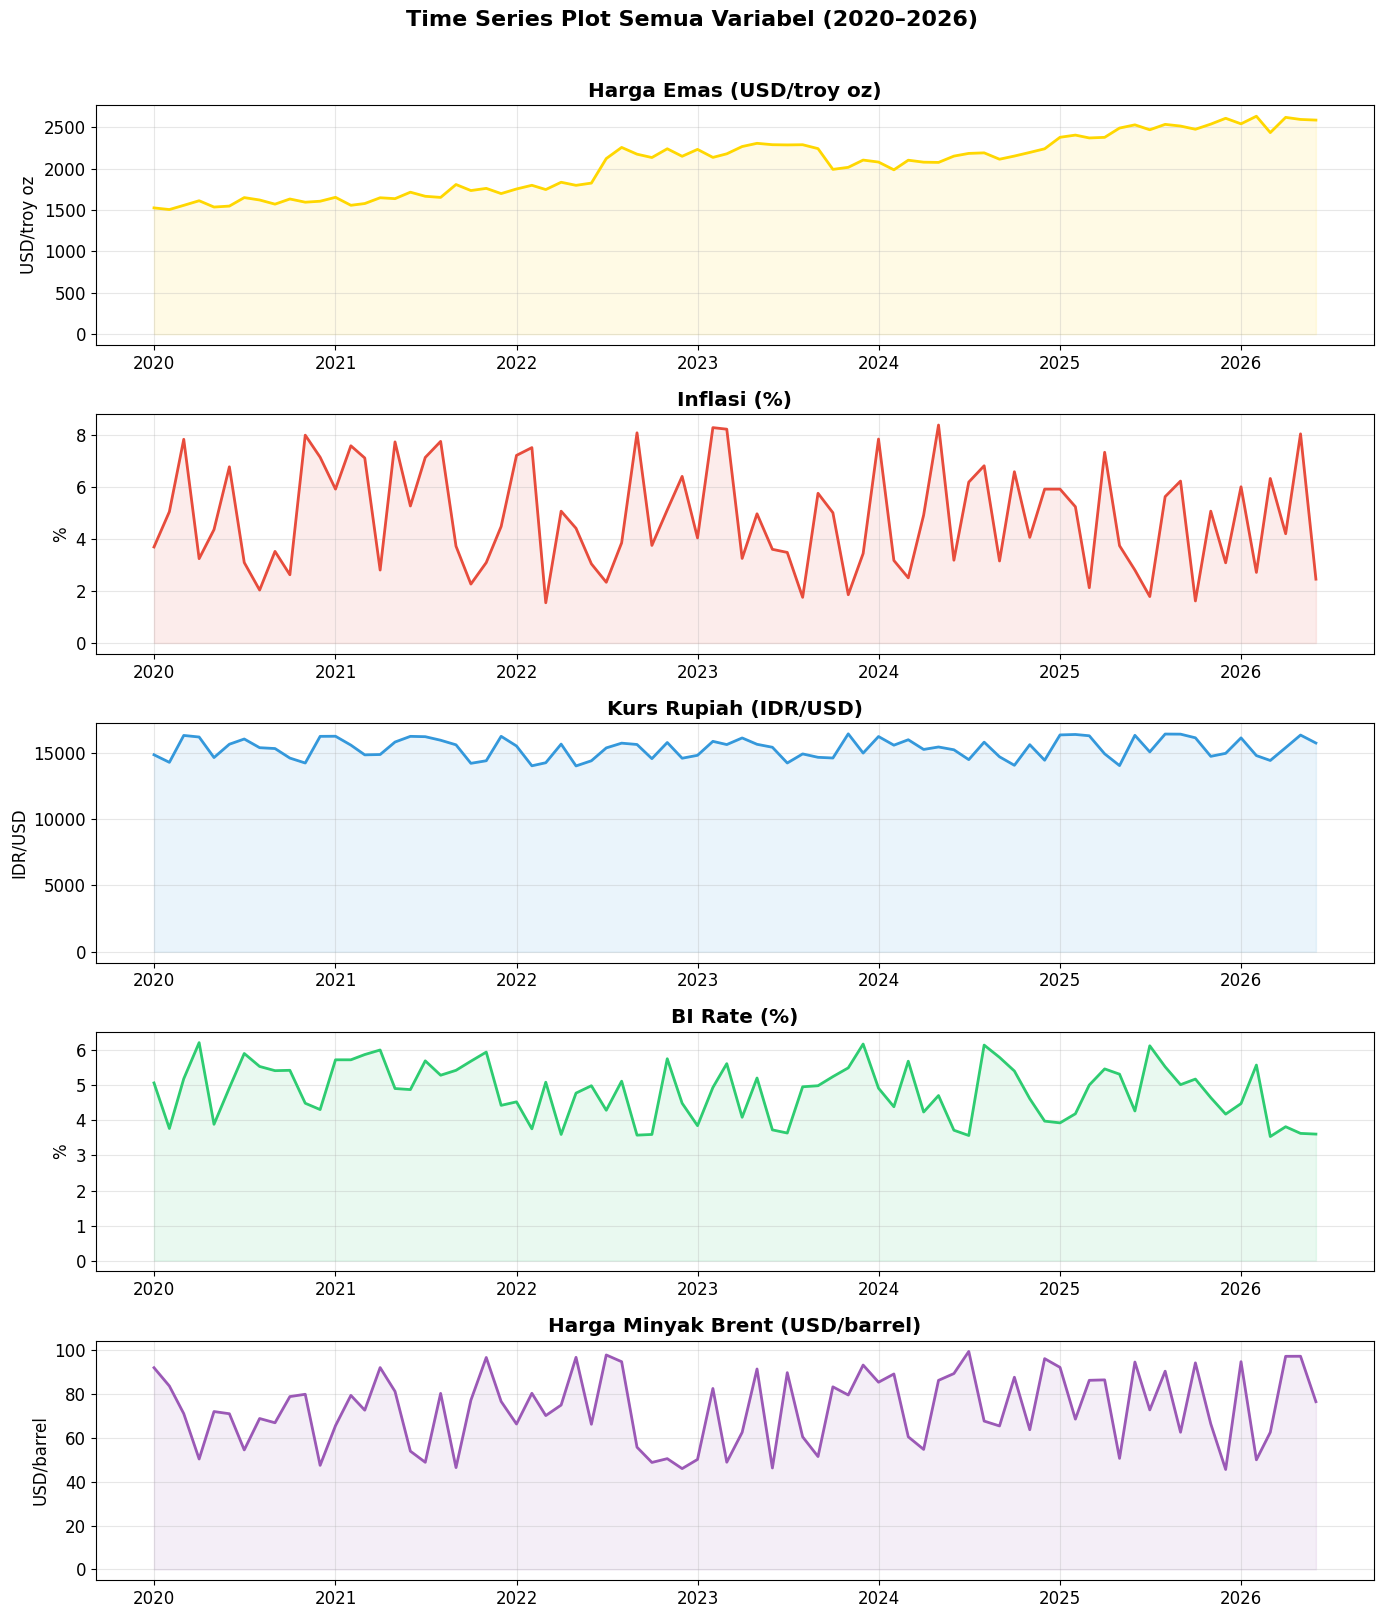

In [4]:
# Visualisasi Time Series semua variabel
fig, axes = plt.subplots(5, 1, figsize=(14, 16))

kolom = ['Harga_Emas', 'Inflasi', 'Kurs_Rupiah', 'BI_Rate', 'Harga_Minyak']
judul = ['Harga Emas (USD/troy oz)', 'Inflasi (%)',
         'Kurs Rupiah (IDR/USD)', 'BI Rate (%)', 'Harga Minyak Brent (USD/barrel)']
warna = ['#FFD700', '#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for i, (col, title, color) in enumerate(zip(kolom, judul, warna)):
    axes[i].plot(df.index, df[col], color=color, linewidth=2)
    axes[i].fill_between(df.index, df[col], alpha=0.1, color=color)
    axes[i].set_title(title, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].set_ylabel(title.split('(')[-1].replace(')', '') if '(' in title else '')

plt.suptitle('Time Series Plot Semua Variabel (2020–2026)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

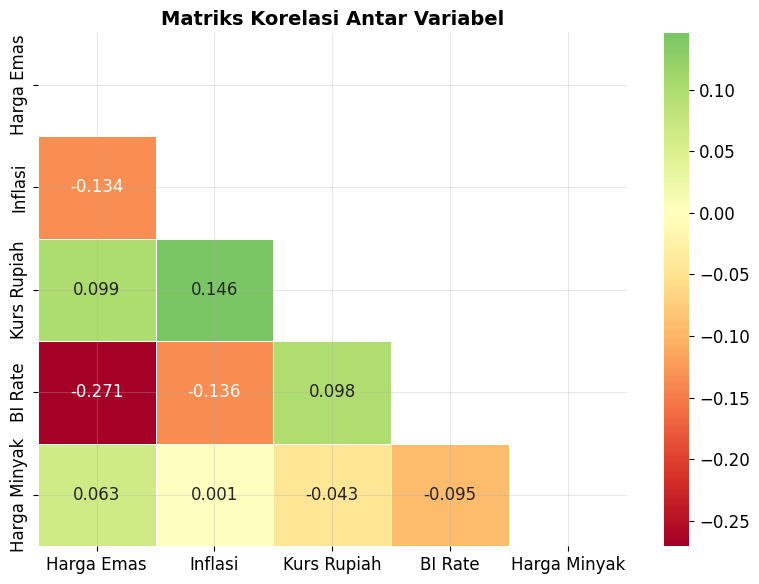


Korelasi dengan Harga Emas:
Kurs_Rupiah     0.099180
Harga_Minyak    0.063066
Inflasi        -0.133903
BI_Rate        -0.270897
Name: Harga_Emas, dtype: float64


In [6]:
# Correlation Matrix
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask,
            xticklabels=['Harga Emas', 'Inflasi', 'Kurs Rupiah', 'BI Rate', 'Harga Minyak'],
            yticklabels=['Harga Emas', 'Inflasi', 'Kurs Rupiah', 'BI Rate', 'Harga Minyak'])
ax.set_title('Matriks Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan Harga Emas:')
print(corr['Harga_Emas'].drop('Harga_Emas').sort_values(ascending=False))

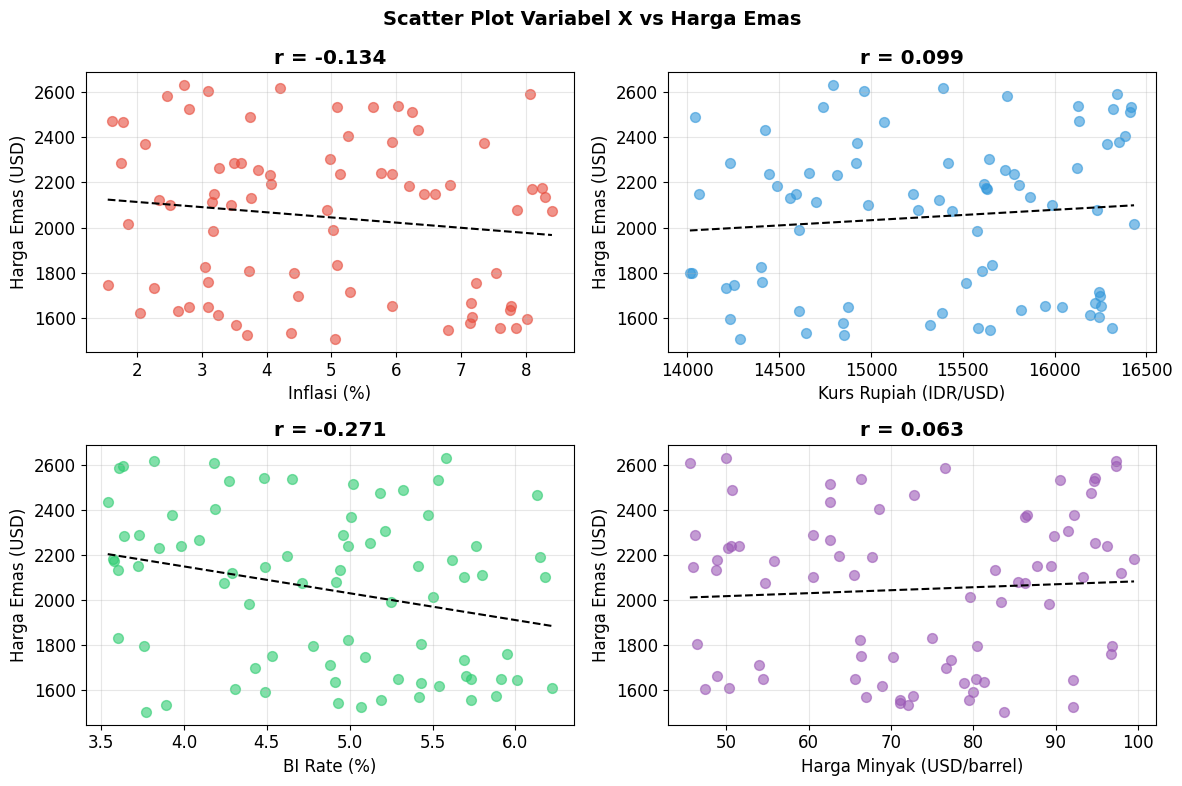

In [7]:
# Scatter Plot: masing-masing variabel X vs Harga Emas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x_vars = ['Inflasi', 'Kurs_Rupiah', 'BI_Rate', 'Harga_Minyak']
x_labels = ['Inflasi (%)', 'Kurs Rupiah (IDR/USD)', 'BI Rate (%)', 'Harga Minyak (USD/barrel)']
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for i, (var, label, color) in enumerate(zip(x_vars, x_labels, colors)):
    axes[i].scatter(df[var], df['Harga_Emas'], alpha=0.6, color=color, s=50)
    z = np.polyfit(df[var], df['Harga_Emas'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend')
    r = df[var].corr(df['Harga_Emas'])
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Harga Emas (USD)')
    axes[i].set_title(f'r = {r:.3f}', fontweight='bold')

plt.suptitle('Scatter Plot Variabel X vs Harga Emas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing Data

In [8]:
# Handle Missing Values (jika ada)
df = df.fillna(method='ffill')  # forward fill
df = df.dropna()  # drop sisa NaN (jika ada di baris pertama)

print(f'Data setelah cleaning: {df.shape}')

# Definisi fitur
feature_cols = ['Harga_Emas', 'Inflasi', 'Kurs_Rupiah', 'BI_Rate', 'Harga_Minyak']
target_col = 'Harga_Emas'

data = df[feature_cols].values

# Normalisasi dengan MinMaxScaler [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Scaler khusus untuk target (untuk inverse transform)
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(df[[target_col]])

print('Data setelah normalisasi (5 baris pertama):')
print(pd.DataFrame(data_scaled[:5], columns=feature_cols).round(4))

Data setelah cleaning: (78, 5)
Data setelah normalisasi (5 baris pertama):
   Harga_Emas  Inflasi  Kurs_Rupiah  BI_Rate  Harga_Minyak
0      0.0178   0.3139       0.3471   0.5709        0.8621
1      0.0000   0.5124       0.1120   0.0858        0.7071
2      0.0452   0.9197       0.9500   0.6157        0.4729
3      0.0945   0.2482       0.9008   1.0000        0.0887
4      0.0269   0.4117       0.2612   0.1306        0.4907


In [9]:
# Fungsi membuat dataset dengan sliding window
def create_sequences(data, look_back=12):
    """
    Membuat sequences untuk LSTM.
    look_back: jumlah timestep sebelumnya yang digunakan untuk prediksi
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :])  # semua fitur
        y.append(data[i, 0])                 # target: indeks 0 = Harga_Emas
    return np.array(X), np.array(y)

# Hyperparameter
LOOK_BACK = 12   # menggunakan 12 bulan sebelumnya
TRAIN_RATIO = 0.8

X_all, y_all = create_sequences(data_scaled, look_back=LOOK_BACK)

# Split Train - Test
train_size = int(len(X_all) * TRAIN_RATIO)
X_train, X_test = X_all[:train_size], X_all[train_size:]
y_train, y_test = y_all[:train_size], y_all[train_size:]

print(f'Look-back window : {LOOK_BACK} bulan')
print(f'Total sampel     : {len(X_all)}')
print(f'Data Train       : {X_train.shape} | {y_train.shape}')
print(f'Data Test        : {X_test.shape} | {y_test.shape}')
print(f'Input shape LSTM : (samples, timesteps, features) = {X_train.shape}')

Look-back window : 12 bulan
Total sampel     : 66
Data Train       : (52, 12, 5) | (52,)
Data Test        : (14, 12, 5) | (14,)
Input shape LSTM : (samples, timesteps, features) = (52, 12, 5)


## 5. Membangun Model LSTM

In [10]:
def build_lstm_model(input_shape, units_1=64, units_2=32, dropout_rate=0.2, learning_rate=0.001):
    """
    Membangun arsitektur LSTM dengan 2 hidden layer.

    Arsitektur:
    - LSTM Layer 1: units_1 unit, return_sequences=True
    - Dropout 1
    - LSTM Layer 2: units_2 unit
    - Dropout 2
    - Dense output: 1 neuron (prediksi harga emas)
    """
    model = Sequential([
        LSTM(units=units_1, return_sequences=True,
             input_shape=input_shape,
             name='lstm_1'),
        Dropout(dropout_rate, name='dropout_1'),

        LSTM(units=units_2, return_sequences=False,
             name='lstm_2'),
        Dropout(dropout_rate, name='dropout_2'),

        Dense(16, activation='relu', name='dense_hidden'),
        Dense(1, name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# Bangun model
input_shape = (X_train.shape[1], X_train.shape[2])  # (look_back, n_features)
model = build_lstm_model(input_shape, units_1=64, units_2=32, dropout_rate=0.2)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# Training
print('Memulai pelatihan model LSTM...')
print('=' * 50)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
    shuffle=False  # Penting untuk time series: jangan diacak
)

print(f'\nTraining selesai pada epoch {len(history.history["loss"])}')

Memulai pelatihan model LSTM...
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - loss: 0.1772 - mae: 0.3844 - val_loss: 0.2705 - val_mae: 0.5159 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0556 - mae: 0.1813 - val_loss: 0.0608 - val_mae: 0.2369 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0441 - mae: 0.1847 - val_loss: 0.0116 - val_mae: 0.0927 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0517 - mae: 0.1896 - val_loss: 0.0112 - val_mae: 0.0908 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0421 - mae: 0.1666 - val_loss: 0.0282 - val_mae: 0.1559 - learning_rate: 0.0010
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0320 - mae: 0.1577 - val_loss: 0.0482 - val_mae: 0.2109 - learning_rate: 0.0010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0282 - mae: 0.1414 - val_loss: 0.0570 - val_mae: 0.2313 - learning_

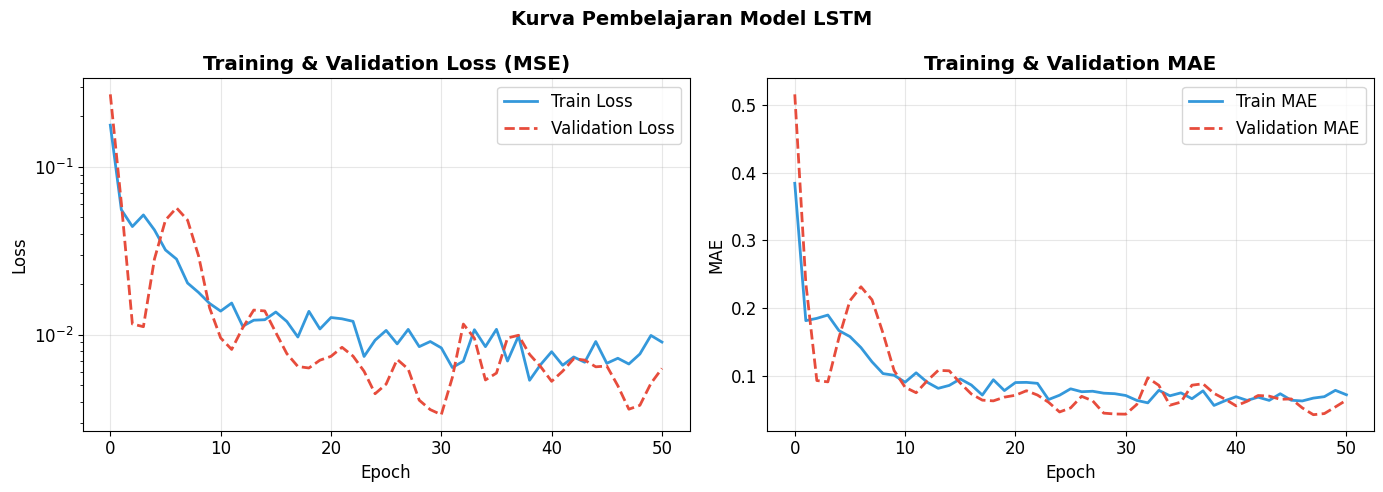

In [12]:
# Plot Loss Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498DB', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#E74C3C',
             linewidth=2, linestyle='--')
axes[0].set_title('Training & Validation Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_yscale('log')

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='#3498DB', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#E74C3C',
             linewidth=2, linestyle='--')
axes[1].set_title('Training & Validation MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Kurva Pembelajaran Model LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prediksi & Evaluasi Model

In [13]:
# Prediksi
y_train_pred_scaled = model.predict(X_train)
y_test_pred_scaled  = model.predict(X_test)

# Inverse transform ke skala asli
def inverse_transform_target(scaled_values, scaler_target):
    return scaler_target.inverse_transform(scaled_values.reshape(-1, 1)).flatten()

y_train_actual = inverse_transform_target(y_train, scaler_target)
y_test_actual  = inverse_transform_target(y_test, scaler_target)
y_train_pred   = inverse_transform_target(y_train_pred_scaled, scaler_target)
y_test_pred    = inverse_transform_target(y_test_pred_scaled, scaler_target)

print('Prediksi berhasil dilakukan.')
print(f'Jumlah prediksi train : {len(y_train_pred)}')
print(f'Jumlah prediksi test  : {len(y_test_pred)}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Prediksi berhasil dilakukan.
Jumlah prediksi train : 52
Jumlah prediksi test  : 14


In [14]:
# Fungsi evaluasi
def evaluate_model(y_actual, y_pred, label=''):
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
    mse  = mean_squared_error(y_actual, y_pred)
    r2   = 1 - (np.sum((y_actual - y_pred)**2) / np.sum((y_actual - np.mean(y_actual))**2))

    print(f'\n--- Evaluasi {label} ---')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  MAPE : {mape:.4f}%')
    print(f'  R²   : {r2:.4f}')

    return {'MAE': mae, 'RMSE': rmse, 'MSE': mse, 'MAPE': mape, 'R2': r2}

metrics_train = evaluate_model(y_train_actual, y_train_pred, 'Data Train')
metrics_test  = evaluate_model(y_test_actual, y_test_pred, 'Data Test')

# Tabel ringkasan
print('\n' + '=' * 45)
print('RINGKASAN EVALUASI MODEL LSTM')
print('=' * 45)
summary = pd.DataFrame({'Train': metrics_train, 'Test': metrics_test})
print(summary.round(4))


--- Evaluasi Data Train ---
  MAE  : 65.9014
  RMSE : 82.4765
  MSE  : 6802.3680
  MAPE : 3.2304%
  R²   : 0.8887

--- Evaluasi Data Test ---
  MAE  : 164.1063
  RMSE : 181.7202
  MSE  : 33022.2279
  MAPE : 6.4034%
  R²   : -8.6271

RINGKASAN EVALUASI MODEL LSTM
          Train        Test
MAE     65.9014    164.1063
RMSE    82.4765    181.7202
MSE   6802.3680  33022.2279
MAPE     3.2304      6.4034
R2       0.8887     -8.6271


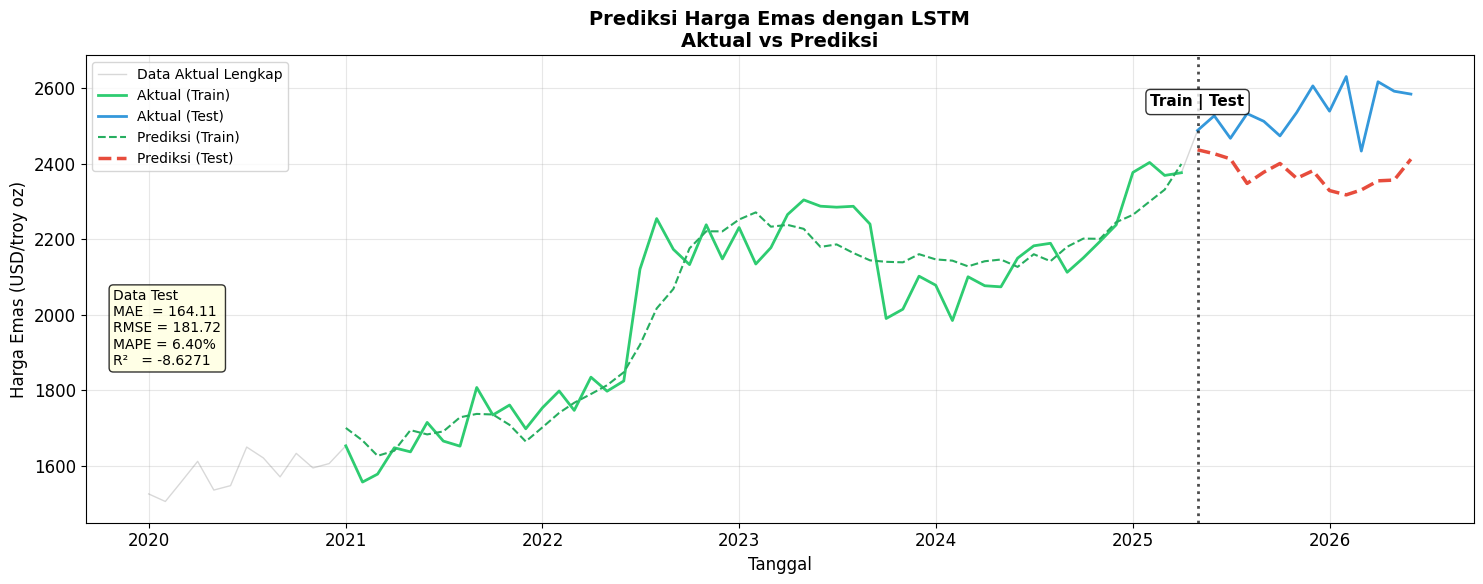

In [15]:
# Indeks waktu untuk plot
idx_all = df.index[LOOK_BACK:]
idx_train = idx_all[:train_size]
idx_test  = idx_all[train_size:]

# Plot Aktual vs Prediksi
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df.index, df['Harga_Emas'], color='gray', alpha=0.3, linewidth=1, label='Data Aktual Lengkap')
ax.plot(idx_train, y_train_actual, color='#2ECC71', linewidth=2, label='Aktual (Train)')
ax.plot(idx_test, y_test_actual, color='#3498DB', linewidth=2, label='Aktual (Test)')
ax.plot(idx_train, y_train_pred, color='#27AE60', linewidth=1.5, linestyle='--', label='Prediksi (Train)')
ax.plot(idx_test, y_test_pred, color='#E74C3C', linewidth=2.5, linestyle='--', label='Prediksi (Test)')

# Garis pemisah train-test
ax.axvline(x=idx_test[0], color='black', linestyle=':', linewidth=2, alpha=0.7)
ax.text(idx_test[0], ax.get_ylim()[1]*0.95, 'Train | Test',
        ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Prediksi Harga Emas dengan LSTM\nAktual vs Prediksi',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga Emas (USD/troy oz)')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotations metrik
textstr = f"Data Test\nMAE  = {metrics_test['MAE']:.2f}\nRMSE = {metrics_test['RMSE']:.2f}\nMAPE = {metrics_test['MAPE']:.2f}%\nR²   = {metrics_test['R2']:.4f}"
ax.text(0.02, 0.5, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('plot_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()

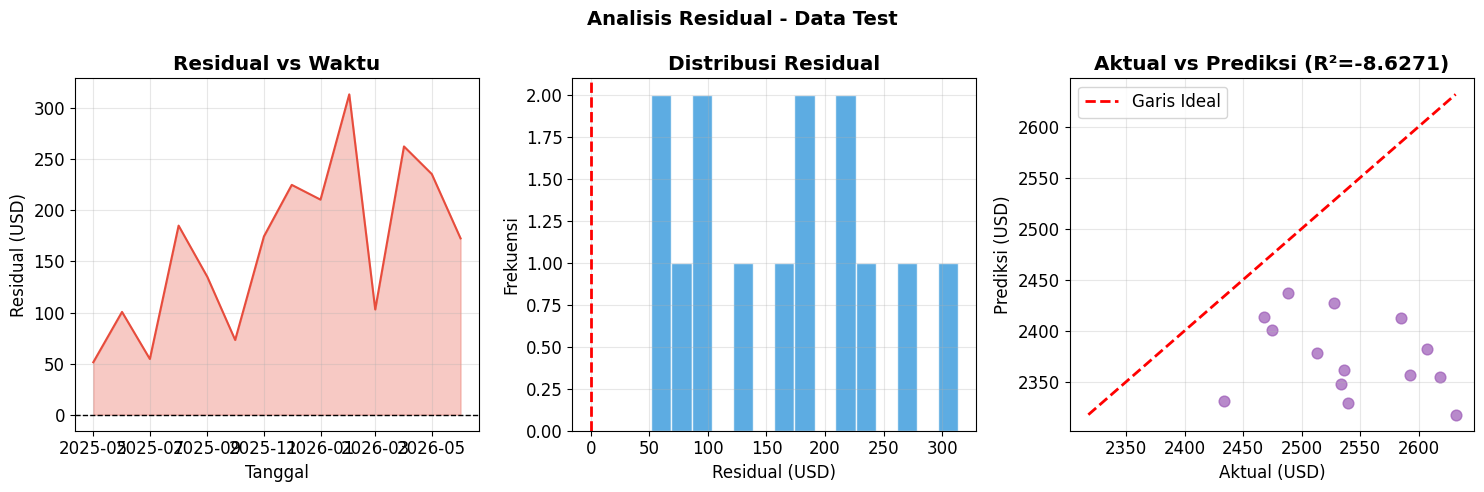

In [16]:
# Residual Plot
residuals = y_test_actual - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residual over time
axes[0].plot(idx_test, residuals, color='#E74C3C', linewidth=1.5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].fill_between(idx_test, residuals, 0, alpha=0.3, color='#E74C3C')
axes[0].set_title('Residual vs Waktu', fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Residual (USD)')

# Histogram residual
axes[1].hist(residuals, bins=15, color='#3498DB', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frekuensi')

# Scatter: Aktual vs Prediksi
axes[2].scatter(y_test_actual, y_test_pred, alpha=0.7, color='#9B59B6', s=60)
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Garis Ideal')
axes[2].set_title(f'Aktual vs Prediksi (R²={metrics_test["R2"]:.4f})', fontweight='bold')
axes[2].set_xlabel('Aktual (USD)')
axes[2].set_ylabel('Prediksi (USD)')
axes[2].legend()

plt.suptitle('Analisis Residual - Data Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_residual.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Forecasting ke Depan (Future Prediction)

In [17]:
def forecast_future(model, data_scaled, scaler_target, look_back=12, n_future=6):
    """
    Prediksi ke depan menggunakan rolling forecast.
    n_future: jumlah bulan ke depan yang diprediksi
    """
    last_sequence = data_scaled[-look_back:].copy()  # shape: (look_back, n_features)
    future_preds_scaled = []

    for _ in range(n_future):
        input_seq = last_sequence.reshape(1, look_back, last_sequence.shape[1])
        pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
        future_preds_scaled.append(pred_scaled)

        # Roll forward: geser 1 timestep, masukkan prediksi di kolom target
        new_row = last_sequence[-1].copy()
        new_row[0] = pred_scaled  # update kolom harga emas
        last_sequence = np.vstack([last_sequence[1:], new_row])

    # Inverse transform
    future_preds = scaler_target.inverse_transform(
        np.array(future_preds_scaled).reshape(-1, 1)
    ).flatten()

    return future_preds

N_FUTURE = 6  # prediksi 6 bulan ke depan
future_preds = forecast_future(model, data_scaled, scaler_target,
                                look_back=LOOK_BACK, n_future=N_FUTURE)

# Buat index tanggal masa depan
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                              periods=N_FUTURE, freq='MS')

df_future = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga_Emas': np.round(future_preds, 2)})
df_future = df_future.set_index('Tanggal')

print(f'Forecast {N_FUTURE} Bulan ke Depan:')
print('=' * 40)
print(df_future.to_string())

Forecast 6 Bulan ke Depan:
            Prediksi_Harga_Emas
Tanggal                        
2026-07-01          2439.080078
2026-08-01          2489.310059
2026-09-01          2517.620117
2026-10-01          2563.300049
2026-11-01          2580.139893
2026-12-01          2584.659912


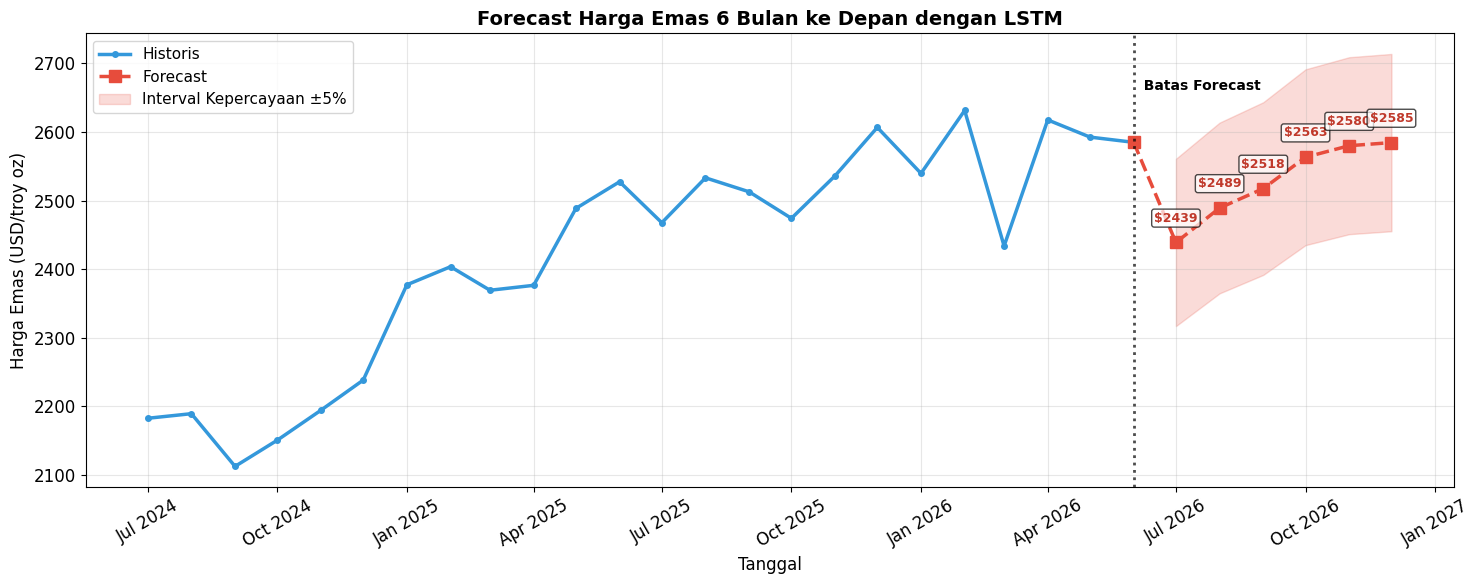

In [18]:
# Plot Forecast
fig, ax = plt.subplots(figsize=(15, 6))

# Data historis (12 bulan terakhir)
hist_plot = df['Harga_Emas'].tail(24)
ax.plot(hist_plot.index, hist_plot.values, color='#3498DB', linewidth=2.5,
        label='Historis', marker='o', markersize=4)

# Forecast
forecast_x = [hist_plot.index[-1]] + list(future_dates)
forecast_y = [hist_plot.values[-1]] + list(future_preds)
ax.plot(forecast_x, forecast_y, color='#E74C3C', linewidth=2.5,
        linestyle='--', label='Forecast', marker='s', markersize=8)

# Confidence interval sederhana (±5%)
ci_upper = np.array(forecast_y[1:]) * 1.05
ci_lower = np.array(forecast_y[1:]) * 0.95
ax.fill_between(future_dates, ci_lower, ci_upper, alpha=0.2, color='#E74C3C',
                label='Interval Kepercayaan ±5%')

# Label nilai forecast
for date, val in zip(future_dates, future_preds):
    ax.annotate(f'${val:.0f}', xy=(date, val), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9, fontweight='bold',
                color='#C0392B',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.axvline(x=hist_plot.index[-1], color='black', linestyle=':', linewidth=2, alpha=0.7)
ax.text(hist_plot.index[-1], ax.get_ylim()[1]*0.97, '  Batas Forecast',
        fontsize=10, color='black', fontweight='bold')

ax.set_title(f'Forecast Harga Emas {N_FUTURE} Bulan ke Depan dengan LSTM',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga Emas (USD/troy oz)')
ax.legend(loc='upper left', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('plot_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Simpan Model & Data

In [19]:
import pickle

# Simpan model
model.save('model_lstm_emas.h5')
print('Model tersimpan: model_lstm_emas.h5')

# Simpan scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('scaler_target.pkl', 'wb') as f:
    pickle.dump(scaler_target, f)
print('Scaler tersimpan: scaler.pkl, scaler_target.pkl')

# Simpan hasil prediksi
df_results = pd.DataFrame({
    'Tanggal': idx_test,
    'Aktual': y_test_actual.round(2),
    'Prediksi': y_test_pred.round(2),
    'Error': (y_test_actual - y_test_pred).round(2),
    'APE (%)': (np.abs(y_test_actual - y_test_pred) / y_test_actual * 100).round(4)
})
df_results.to_csv('hasil_prediksi_test.csv', index=False)
print('Hasil prediksi tersimpan: hasil_prediksi_test.csv')

# Simpan data asli + scaler info
df.to_csv('data_clean.csv')
df_future.to_csv('hasil_forecast_future.csv')
print('Data tersimpan: data_clean.csv, hasil_forecast_future.csv')

print('\n✓ Semua file berhasil disimpan!')

Model tersimpan: model_lstm_emas.h5
Scaler tersimpan: scaler.pkl, scaler_target.pkl
Hasil prediksi tersimpan: hasil_prediksi_test.csv
Data tersimpan: data_clean.csv, hasil_forecast_future.csv

✓ Semua file berhasil disimpan!


## 9. Ringkasan Akhir

In [20]:
print('=' * 60)
print('        RINGKASAN PROYEK EAS - PREDIKSI HARGA EMAS')
print('=' * 60)
print(f"Metode          : Long Short-Term Memory (LSTM)")
print(f"Variabel Input  : Inflasi, Kurs Rupiah, BI Rate, Harga Minyak")
print(f"Target          : Harga Emas (USD/troy oz)")
print(f"Periode Data    : {df.index.min().strftime('%B %Y')} - {df.index.max().strftime('%B %Y')}")
print(f"Arsitektur      : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16) → Dense(1)")
print(f"Look-back       : {LOOK_BACK} bulan")
print(f"Split Data      : {TRAIN_RATIO*100:.0f}% Train / {(1-TRAIN_RATIO)*100:.0f}% Test")
print(f"Total Epoch     : {len(history.history['loss'])}")
print()
print('--- PERFORMA MODEL (DATA TEST) ---')
print(f"  MAE   : {metrics_test['MAE']:.4f} USD")
print(f"  RMSE  : {metrics_test['RMSE']:.4f} USD")
print(f"  MAPE  : {metrics_test['MAPE']:.4f}%")
print(f"  R²    : {metrics_test['R2']:.4f}")
print()
print('--- FORECAST 6 BULAN KE DEPAN ---')
for date, val in zip(future_dates, future_preds):
    print(f"  {date.strftime('%B %Y'):15s}: ${val:.2f}")
print('=' * 60)

        RINGKASAN PROYEK EAS - PREDIKSI HARGA EMAS
Metode          : Long Short-Term Memory (LSTM)
Variabel Input  : Inflasi, Kurs Rupiah, BI Rate, Harga Minyak
Target          : Harga Emas (USD/troy oz)
Periode Data    : January 2020 - June 2026
Arsitektur      : LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16) → Dense(1)
Look-back       : 12 bulan
Split Data      : 80% Train / 20% Test
Total Epoch     : 51

--- PERFORMA MODEL (DATA TEST) ---
  MAE   : 164.1063 USD
  RMSE  : 181.7202 USD
  MAPE  : 6.4034%
  R²    : -8.6271

--- FORECAST 6 BULAN KE DEPAN ---
  July 2026      : $2439.07
  August 2026    : $2489.31
  September 2026 : $2517.62
  October 2026   : $2563.30
  November 2026  : $2580.14
  December 2026  : $2584.66
